In [1]:
!pip install ultralytics opencv-python tqdm pillow matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.8 MB/s eta 0:00:00


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [3]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/face-mask-detection")
print("Путь к датасету:", path)

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Путь к датасету: /kaggle/input/face-mask-detection


In [4]:
import os

for f in os.listdir(path):
    print(f)

annotations
images


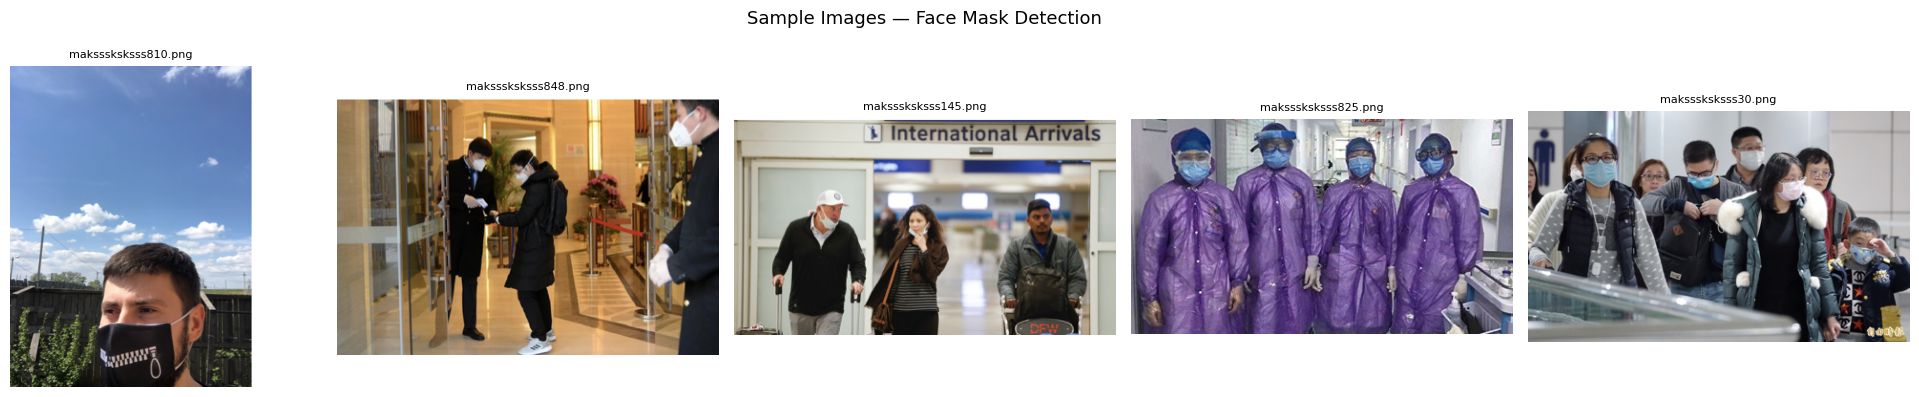

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image

images_path = os.path.join(path, "images")
image_files = os.listdir(images_path)[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, fname in zip(axes, image_files):
    img = Image.open(os.path.join(images_path, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Images — Face Mask Detection", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
import os
import random
import shutil
import xml.etree.ElementTree as ET
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

INPUT_IMAGES      = os.path.join(path, "images")
INPUT_ANNOTATIONS = os.path.join(path, "annotations")
WORKING_DIR       = 'yolo_working'

In [7]:
dirs = ['images/train', 'images/val', 'labels/train', 'labels/val']

for d in dirs:
    os.makedirs(os.path.join(WORKING_DIR, d), exist_ok=True)

In [8]:
class_dict = {'with_mask': 0, 'mask_weared_incorrect': 1, 'without_mask': 2}

def convert_to_yolo_format(xml_file, img_width, img_height):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    yolo_data = []

    for obj in root.findall('object'):
        name = obj.find('name').text
        if name not in class_dict:
            continue

        label = class_dict[name]

        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width    = (xmax - xmin) / img_width
        height   = (ymax - ymin) / img_height

        yolo_data.append(f"{label} {x_center} {y_center} {width} {height}")

    return yolo_data

In [9]:
image_files = [f for f in os.listdir(INPUT_IMAGES) if f.endswith('.png')]
train_files, val_files = train_test_split(image_files, test_size=0.2, random_state=42)

def process_files(files, split_type):
    print(f"Обработка {len(files)} файлов для {split_type}...")

    for filename in tqdm(files):
        src_img_path = os.path.join(INPUT_IMAGES, filename)
        xml_filename = filename.replace('.png', '.xml')
        src_xml_path = os.path.join(INPUT_ANNOTATIONS, xml_filename)

        img = Image.open(src_img_path)
        w, h = img.size

        if os.path.exists(src_xml_path):
            yolo_annotations = convert_to_yolo_format(src_xml_path, w, h)

            dst_img_path = os.path.join(WORKING_DIR, 'images', split_type, filename)
            shutil.copy(src_img_path, dst_img_path)

            txt_filename   = filename.replace('.png', '.txt')
            dst_label_path = os.path.join(WORKING_DIR, 'labels', split_type, txt_filename)

            with open(dst_label_path, 'w') as f:
                f.write('\n'.join(yolo_annotations))


process_files(train_files, 'train')
process_files(val_files,   'val')

Обработка 682 файлов для train...


100%|██████████| 682/682 [00:09<00:00, 73.78it/s]


Обработка 171 файлов для val...


100%|██████████| 171/171 [00:02<00:00, 79.44it/s]


In [10]:
import os

yaml_content = f"""
train: {os.path.abspath(WORKING_DIR)}/images/train
val:   {os.path.abspath(WORKING_DIR)}/images/val

nc: 3
names: ['with_mask', 'mask_weared_incorrect', 'without_mask']
"""

yaml_path = os.path.join(WORKING_DIR, 'dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(yaml_content)


train: /content/yolo_working/images/train
val:   /content/yolo_working/images/val

nc: 3
names: ['with_mask', 'mask_weared_incorrect', 'without_mask']



In [ ]:
from ultralytics import YOLO
import os

model = YOLO('yolov8n.pt')

results = model.train(
    data    = os.path.join(WORKING_DIR, 'dataset.yaml'),
    epochs  = 20,
    imgsz   = 640,
    batch   = 16,
    name    = 'mask_model',
    project = os.path.join(WORKING_DIR, 'runs/detect')
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_working/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

In [ ]:
import glob

found = (
    glob.glob(f'{WORKING_DIR}/**/best.pt', recursive=True) or
    glob.glob('/content/**/best.pt', recursive=True) or
    glob.glob('runs/**/best.pt', recursive=True)
)

if not found:
    for root, dirs, files in os.walk('.'):
        for f in files:
            if f == 'best.pt':
                found.append(os.path.join(root, f))

print('best.pt найден:', found)

best.pt найден: ['/content/runs/detect/yolo_working/runs/detect/mask_model/weights/best.pt']


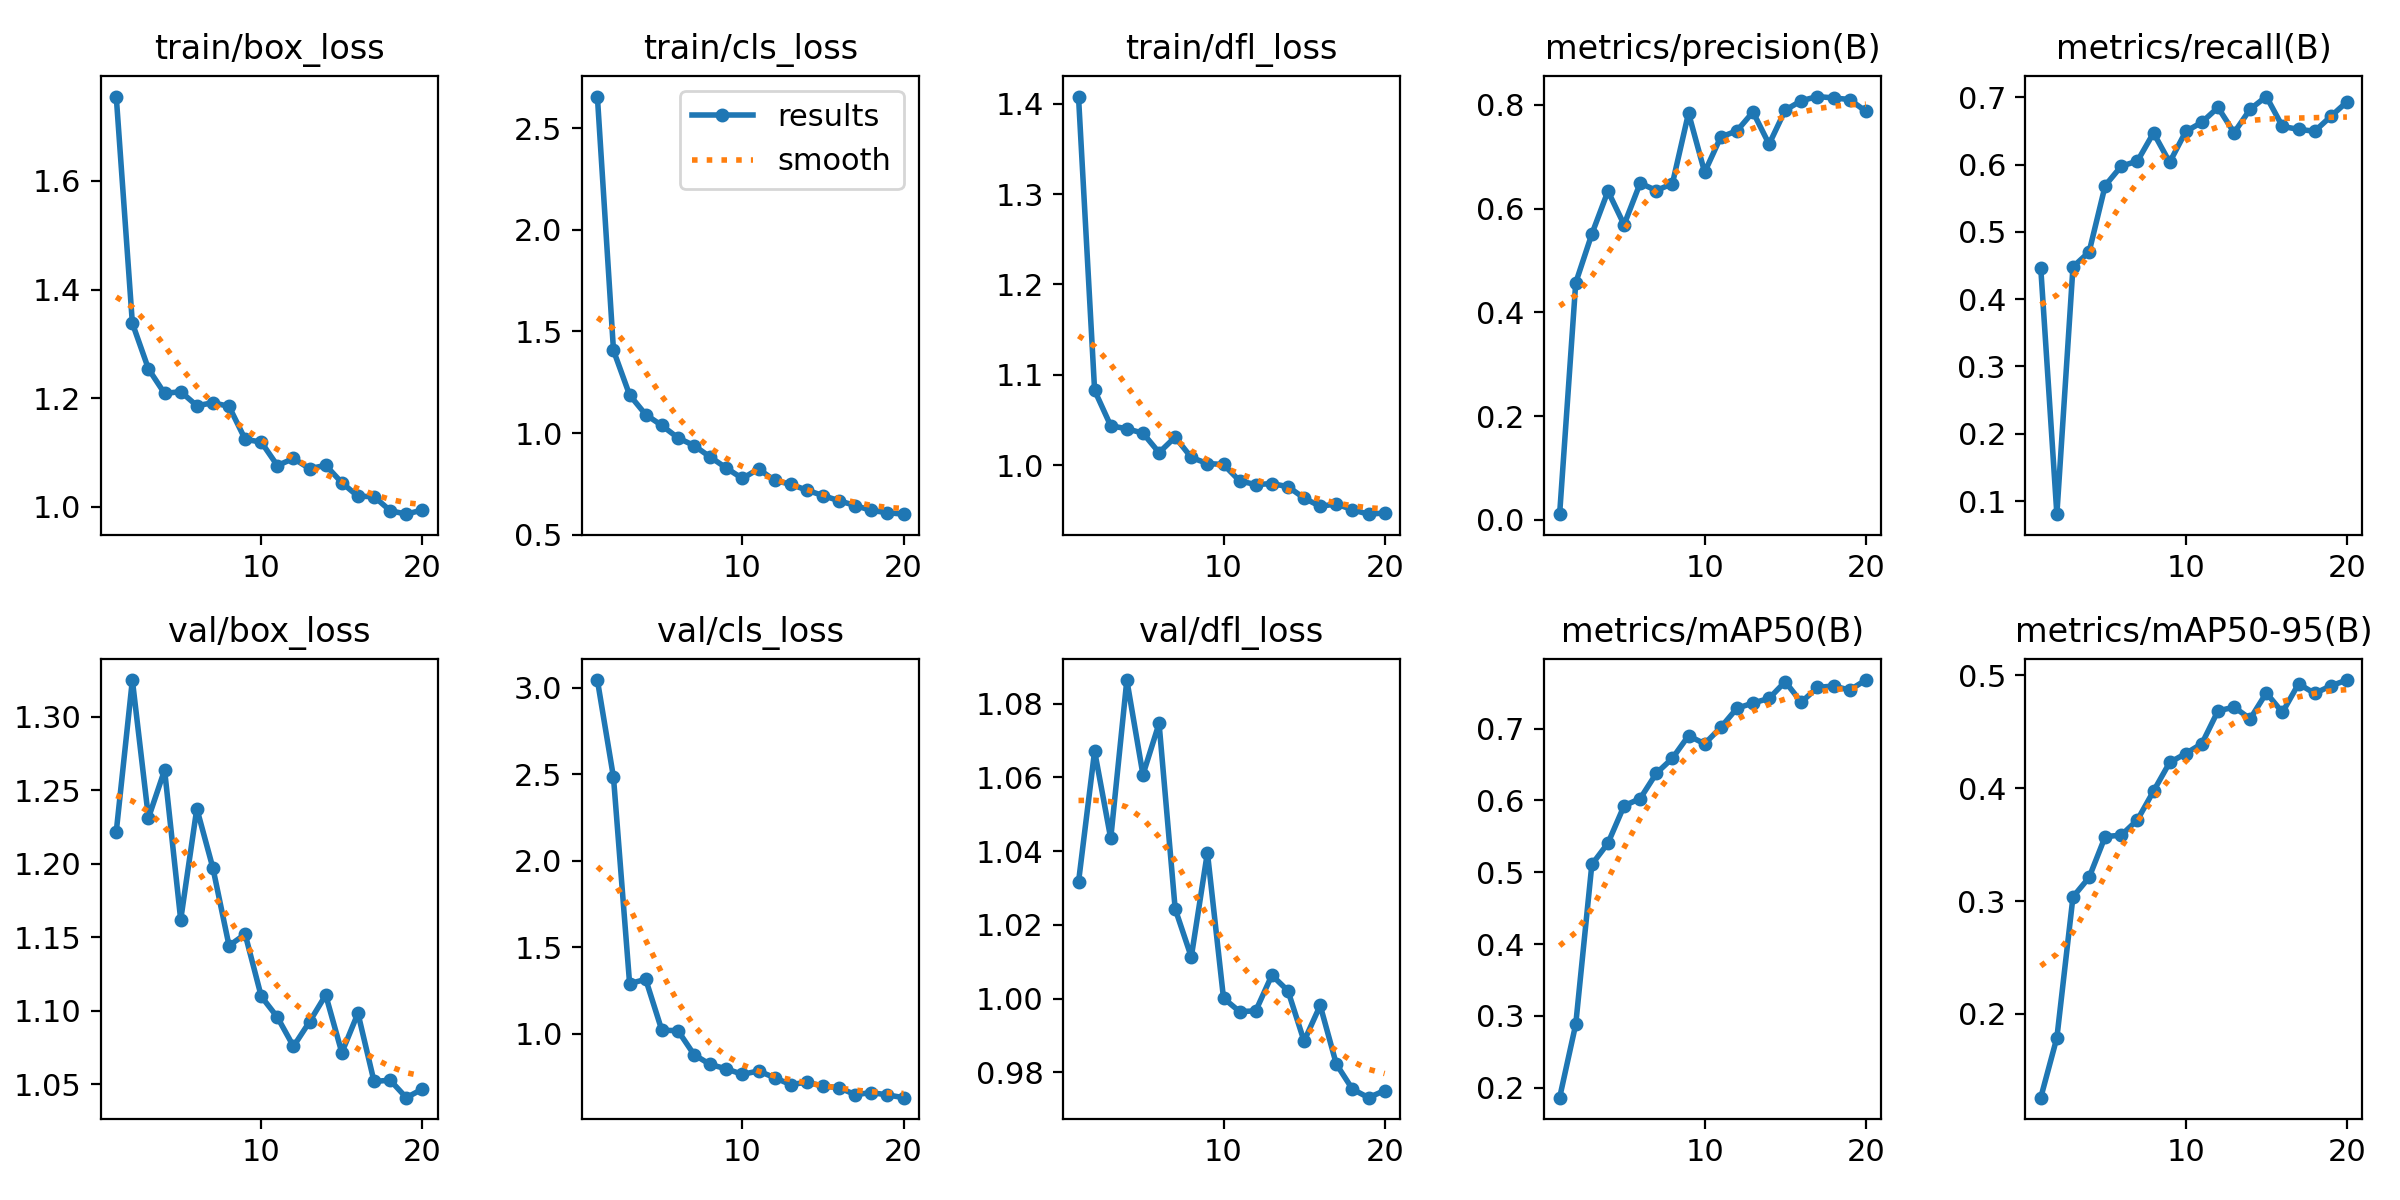

In [13]:
from IPython.display import Image as IPImage, display
import glob, os

results_candidates = glob.glob(f'{WORKING_DIR}/**/results.png', recursive=True)
if not results_candidates:
    results_candidates = glob.glob('/content/**/results.png', recursive=True)

if results_candidates:
    display(IPImage(results_candidates[0]))
else:
    print("results.png не найден")

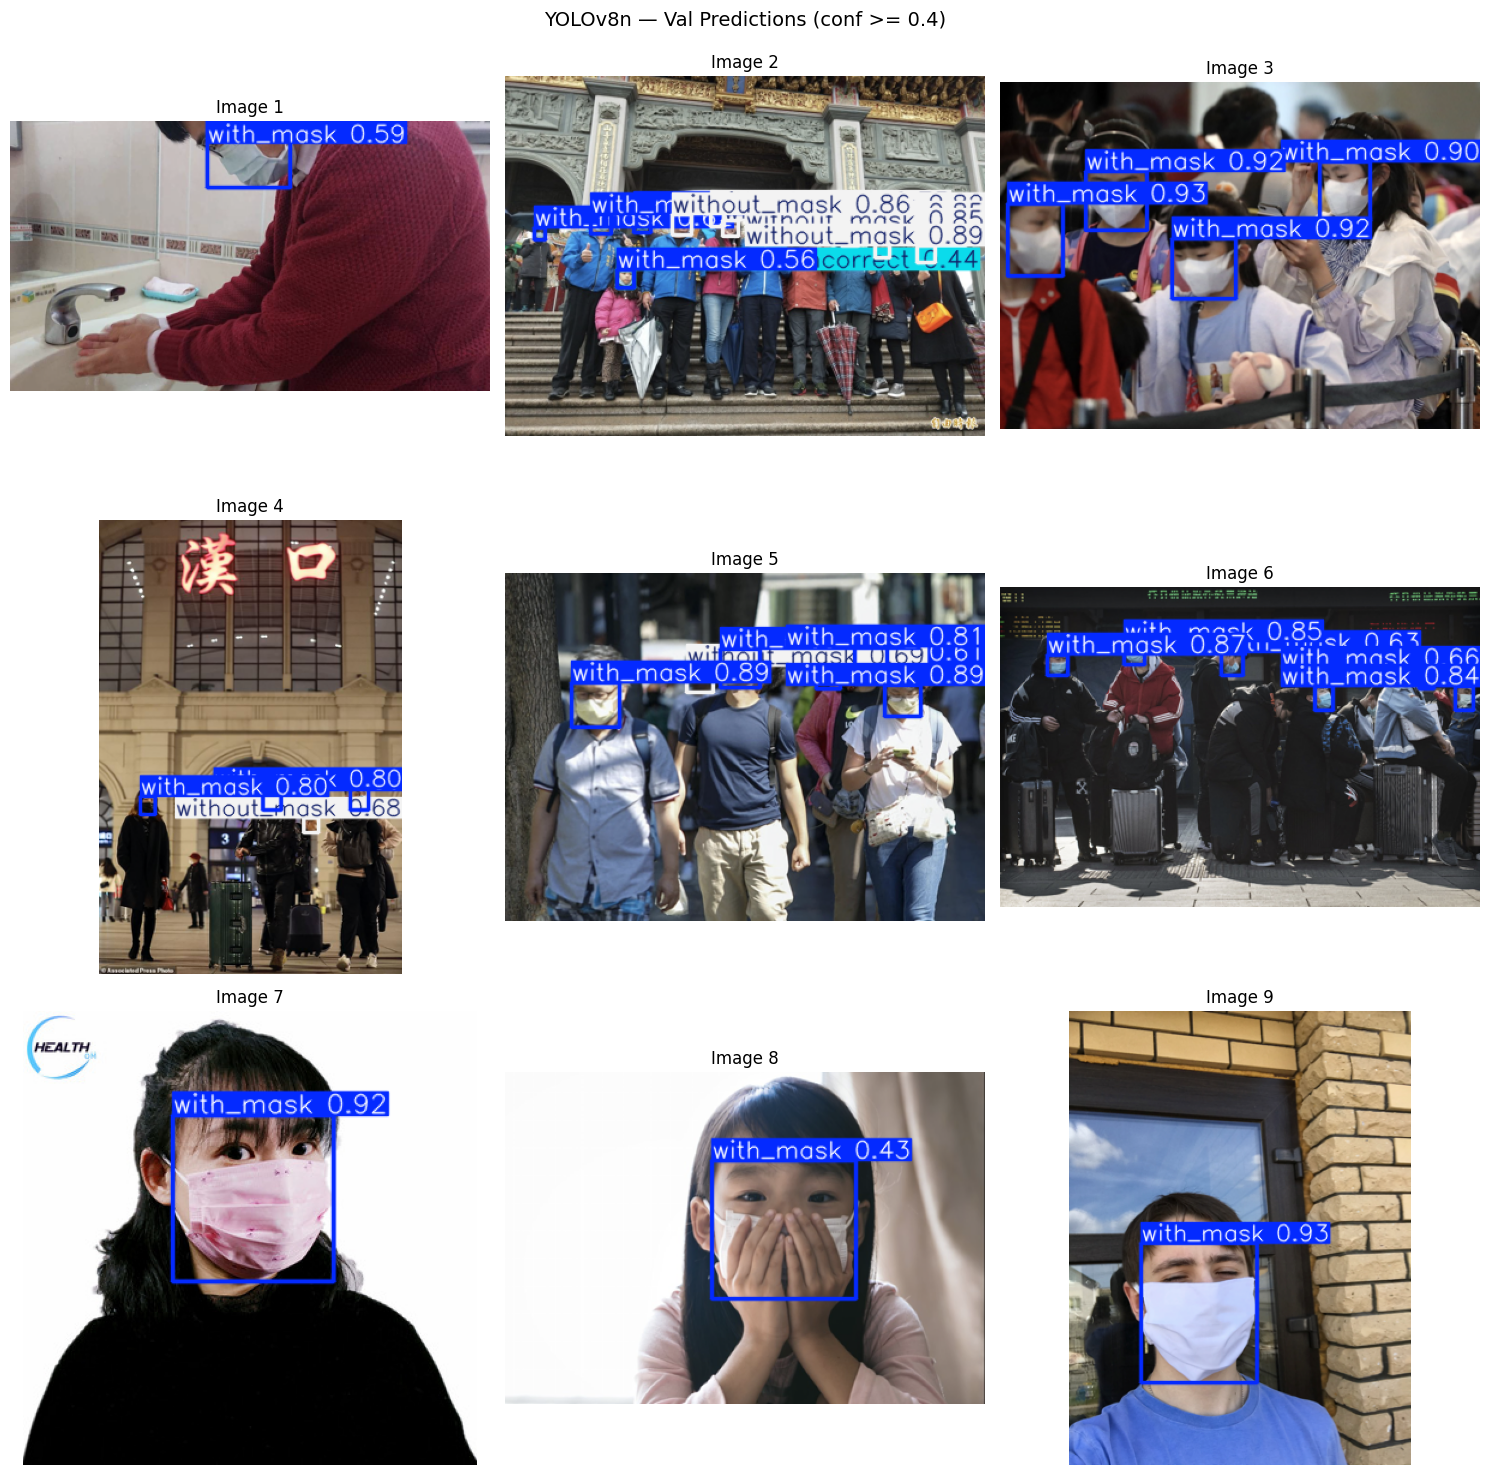

In [ ]:
%matplotlib inline
import glob, os, math, cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

if found:
    BEST_PT    = found[0]
    model_yolo = YOLO(BEST_PT)
else:
    print('best.pt не найден — используем модель напрямую из train()')
    model_yolo = model  

val_images_dir = os.path.join(WORKING_DIR, 'images/val')
val_images = [
    os.path.join(val_images_dir, f)
    for f in os.listdir(val_images_dir)
    if f.endswith(('.png', '.jpg'))
][:9]

all_predicted_images = []
for img_path in val_images:
    res = model_yolo.predict(img_path, conf=0.4, save=False, verbose=False)
    res_plotted = res[0].plot()
    all_predicted_images.append(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))

cols = 3
rows = math.ceil(len(all_predicted_images) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, img in enumerate(all_predicted_images):
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Image {i+1}")

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('YOLOv8n — Val Predictions (conf >= 0.4)', fontsize=14)
plt.tight_layout()
plt.show()